In [14]:
# Importing necessary libraries for analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [15]:
import pandas as pd

df = pd.read_csv(r"C:\Users\HarishNew\Data Analyst project\Product-User-Funnel-Analytics\Data\Processed\final_d2c_marketing_funnel_data.csv")

df.head()

,user_id,session_id,date,month,channel,campaign_type,device,user_type,region,visited_website,...,discount_applied,order_value,revenue,funnel_stage,funnel_dropoff_stage,funnel_depth,month_name,cart_abandoned,checkout_abandoned,high_intent_session
0,221958,1,2025-08-16,2025-08,Organic,New Launch,Mobile,New,Metro,1,...,0,499.00,0.000,Visited Website,Product View,1,August,0,0,0
1,771155,2,2025-12-16,2025-12,Organic,Influencer,Mobile,New,Non-Metro,1,...,0,499.00,0.000,Added to Cart,Checkout,3,December,1,0,1
2,231932,3,2025-07-17,2025-07,Organic,Influencer,Mobile,New,Non-Metro,1,...,0,499.00,0.000,Viewed Product,Add to Cart,2,July,0,0,0
3,465838,4,2025-07-04,2025-07,Paid Ads,Discount,Mobile,Returning,Metro,1,...,1,2000.95,1800.855,Purchased,No Drop-off,5,July,0,0,1
4,359178,5,2025-08-10,2025-08,Paid Ads,Influencer,Mobile,Returning,Non-Metro,1,...,0,499.00,0.000,Visited Website,Product View,1,August,0,0,0


In [16]:
df["month_name"].unique()

array(['August', 'December', 'July', 'November', 'October', 'September'],
      dtype=object)

In [17]:
df.columns

Index(['user_id', 'session_id', 'date', 'month', 'channel', 'campaign_type',
       'device', 'user_type', 'region', 'visited_website', 'viewed_product',
       'added_to_cart', 'checkout_started', 'purchase_completed',
       'discount_applied', 'order_value', 'revenue', 'funnel_stage',
       'funnel_dropoff_stage', 'funnel_depth', 'month_name', 'cart_abandoned',
       'checkout_abandoned', 'high_intent_session'],
      dtype='object')

### 1. Overall Funnel Performance

**Calculate the number of sessions at each stage**

In [18]:
funnel = {
    "Website Visit": df["visited_website"].sum(),
    "Product View": df["viewed_product"].sum(),
    "Add to Cart": df["added_to_cart"].sum(),
    "Checkout Started": df["checkout_started"].sum(),
    "Purchase Completed": df["purchase_completed"].sum()
}

funnel

{'Website Visit': np.int64(120000),
 'Product View': np.int64(77870),
 'Add to Cart': np.int64(27156),
 'Checkout Started': np.int64(16234),
 'Purchase Completed': np.int64(8181)}

In [19]:
funnel_df = pd.DataFrame(
    funnel.items(),
    columns = ["stage","sessions"]
)

funnel_df

,stage,sessions
0,Website Visit,120000
1,Product View,77870
2,Add to Cart,27156
3,Checkout Started,16234
4,Purchase Completed,8181


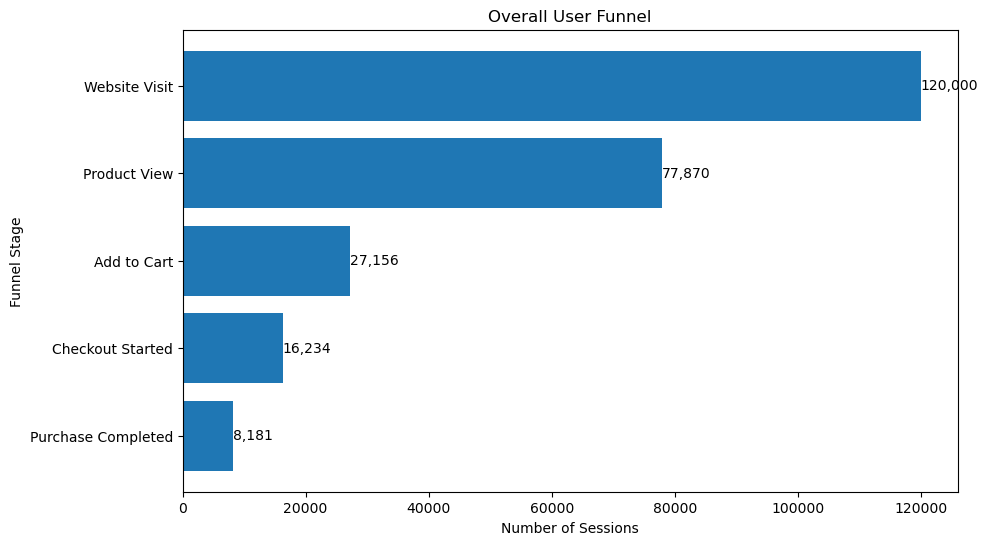

In [20]:
plt.figure(figsize=(10, 6))

plt.barh(
    funnel_df["stage"],
    funnel_df["sessions"]
)

for i, value in enumerate(funnel_df["sessions"]):
    plt.text(
        value,
        i,
        f"{value:,}",
        va="center"
)
plt.xlabel("Number of Sessions")
plt.ylabel("Funnel Stage")
plt.title("Overall User Funnel")

plt.gca().invert_yaxis()

plt.show()

### 2.Funnel Drop-off Analysis
**Calculate overall conversion %**

In [21]:
funnel_df["conversion_from_start"] = ((
    funnel_df["sessions"] /  
    funnel_df["sessions"].iloc[0]
)*100).round(2)

funnel_df            

,stage,sessions,conversion_from_start
0,Website Visit,120000,100.00
1,Product View,77870,64.89
2,Add to Cart,27156,22.63
3,Checkout Started,16234,13.53
4,Purchase Completed,8181,6.82


**Calculate stage-to-stage conversion**

In [22]:
funnel_df["stage_conversion"] = ((
    funnel_df["sessions"]/
    funnel_df["sessions"].shift(1)
)*100).round(2)

funnel_df

,stage,sessions,conversion_from_start,stage_conversion
0,Website Visit,120000,100.00,NaN
1,Product View,77870,64.89,64.89
2,Add to Cart,27156,22.63,34.87
3,Checkout Started,16234,13.53,59.78
4,Purchase Completed,8181,6.82,50.39


**Calculate drop-off %**

In [23]:
funnel_df["dropoff_rate"] = (
    1 - funnel_df["stage_conversion"] / 100
) * 100

funnel_df

,stage,sessions,conversion_from_start,stage_conversion,dropoff_rate
0,Website Visit,120000,100.00,NaN,NaN
1,Product View,77870,64.89,64.89,35.11
2,Add to Cart,27156,22.63,34.87,65.13
3,Checkout Started,16234,13.53,59.78,40.22
4,Purchase Completed,8181,6.82,50.39,49.61


**Calculate absolute drop-off**

In [24]:
funnel_df["sessions_lost"] = (
    funnel_df["sessions"].shift(1) -
    funnel_df["sessions"]
)

funnel_df

,stage,sessions,conversion_from_start,stage_conversion,dropoff_rate,sessions_lost
0,Website Visit,120000,100.00,NaN,NaN,NaN
1,Product View,77870,64.89,64.89,35.11,42130.0
2,Add to Cart,27156,22.63,34.87,65.13,50714.0
3,Checkout Started,16234,13.53,59.78,40.22,10922.0
4,Purchase Completed,8181,6.82,50.39,49.61,8053.0


In [25]:
transitions = [
    None,
    "Website → Product",
    "Product → Cart",
    "Cart → Checkout",
    "Checkout → Purchase"
]

funnel_df["transition"] = transitions

In [26]:
funnel_df

,stage,sessions,conversion_from_start,stage_conversion,dropoff_rate,sessions_lost,transition
0,Website Visit,120000,100.00,NaN,NaN,NaN,None
1,Product View,77870,64.89,64.89,35.11,42130.0,Website → Product
2,Add to Cart,27156,22.63,34.87,65.13,50714.0,Product → Cart
3,Checkout Started,16234,13.53,59.78,40.22,10922.0,Cart → Checkout
4,Purchase Completed,8181,6.82,50.39,49.61,8053.0,Checkout → Purchase


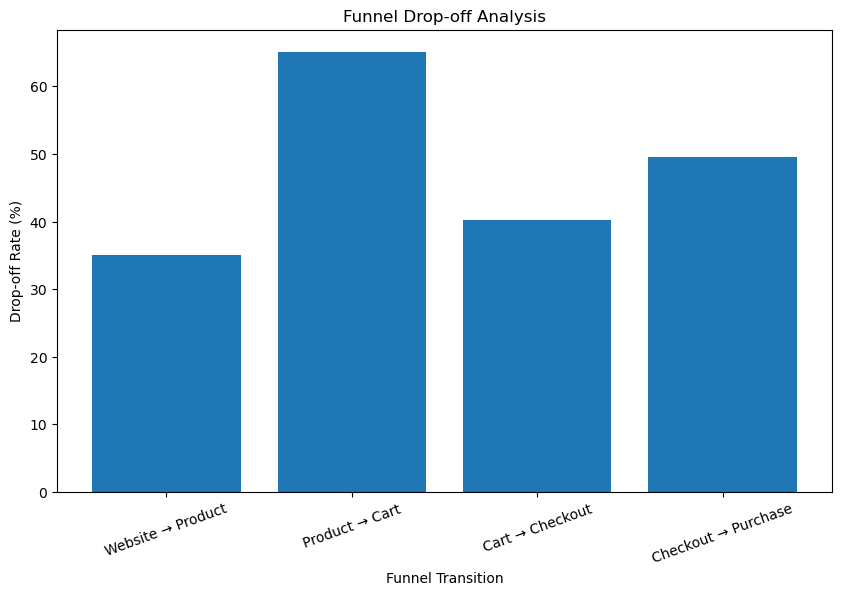

In [27]:
dropoff_df = funnel_df.dropna(subset=["transition"])

plt.figure(figsize=(10, 6))

plt.bar(
    dropoff_df["transition"],
    dropoff_df["dropoff_rate"]
)

plt.xlabel("Funnel Transition")
plt.ylabel("Drop-off Rate (%)")
plt.title("Funnel Drop-off Analysis")

plt.xticks(rotation=20)

plt.show()

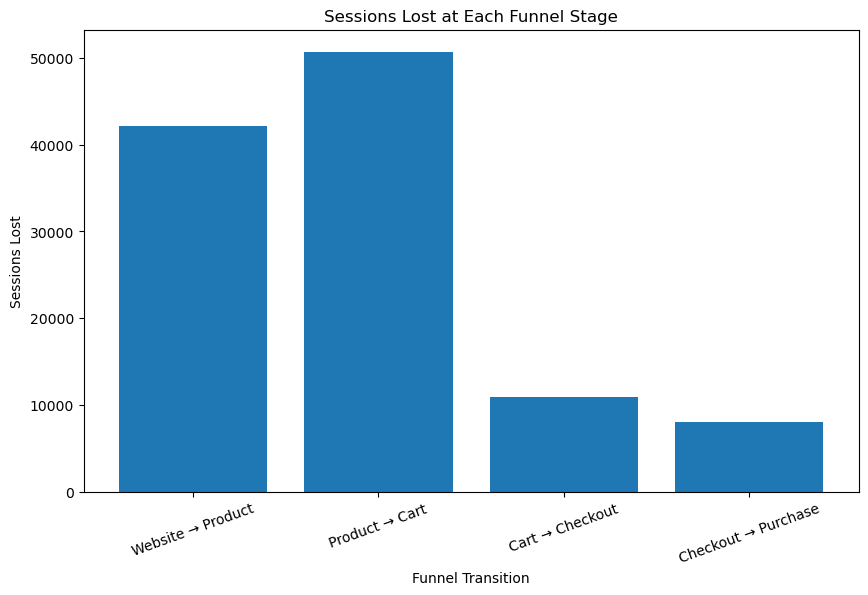

In [28]:
plt.figure(figsize=(10, 6))

plt.bar(
    dropoff_df["transition"],
    dropoff_df["sessions_lost"]
)

plt.xlabel("Funnel Transition")
plt.ylabel("Sessions Lost")
plt.title("Sessions Lost at Each Funnel Stage")

plt.xticks(rotation=20)

plt.show()

**Insights**
- The overall funnel generated 120,000 website-visit sessions, but only 8,181 sessions resulted in a purchase, giving an overall conversion rate of 6.82%.
- The first significant drop-off occurs between Website Visit → Product View, where 35.11% of sessions are lost. This indicates that a considerable number of visitors do not progress to product evaluation.
- The largest bottleneck is Product View → Add to Cart, with a 65.13% drop-off. This results in 50,714 lost sessions, making it the most important stage to investigate and optimize.
- Cart → Checkout performs relatively better, with a 59.78% conversion rate. However, 40.22% of cart sessions still drop off, representing another opportunity to improve the purchase journey.
- The Checkout → Purchase stage has a 49.61% drop-off, meaning almost half of users who start checkout don't complete their purchase. This is the second major funnel problem and could have a direct impact on revenue.

### 3 Funnel Analysis by Device

In [29]:
df["device"].value_counts()

device
Mobile     84006
Desktop    35994
Name: count, dtype: int64

In [30]:
df.columns

Index(['user_id', 'session_id', 'date', 'month', 'channel', 'campaign_type',
       'device', 'user_type', 'region', 'visited_website', 'viewed_product',
       'added_to_cart', 'checkout_started', 'purchase_completed',
       'discount_applied', 'order_value', 'revenue', 'funnel_stage',
       'funnel_dropoff_stage', 'funnel_depth', 'month_name', 'cart_abandoned',
       'checkout_abandoned', 'high_intent_session'],
      dtype='object')

In [31]:
device_funnel = df.groupby("device").agg(
     website_visit = ("visited_website","sum"),
     product_views=("viewed_product", "sum"),
     add_to_cart=("added_to_cart", "sum"),
     checkout_started=("checkout_started", "sum"),
     purchases=("purchase_completed", "sum")
).reset_index()

device_funnel

,device,website_visit,product_views,add_to_cart,checkout_started,purchases
0,Desktop,35994,23373,8140,4893,2488
1,Mobile,84006,54497,19016,11341,5693


**overall conversion by device**

In [32]:
device_funnel["convertion_rate"] = ((device_funnel["purchases"]/
                    device_funnel["website_visit"])*100).round(2)

device_funnel

,device,website_visit,product_views,add_to_cart,checkout_started,purchases,convertion_rate
0,Desktop,35994,23373,8140,4893,2488,6.91
1,Mobile,84006,54497,19016,11341,5693,6.78


**Calculate stage conversion for each device**

In [33]:
device_funnel["website_to_product"] = ((
    device_funnel["product_views"] /
    device_funnel["website_visit"]
) * 100).round(2)


device_funnel["product_to_cart"] = ((
    device_funnel["add_to_cart"] /
    device_funnel["product_views"]
) * 100).round(2)

device_funnel["cart_to_checkout"] = ((
    device_funnel["checkout_started"] /
    device_funnel["add_to_cart"]
) * 100).round(2)

device_funnel["checkout_to_purchase"] = ((
    device_funnel["purchases"] /
    device_funnel["checkout_started"]
) * 100).round(2)

device_funnel

,device,website_visit,product_views,add_to_cart,checkout_started,purchases,convertion_rate,website_to_product,product_to_cart,cart_to_checkout,checkout_to_purchase
0,Desktop,35994,23373,8140,4893,2488,6.91,64.94,34.83,60.11,50.85
1,Mobile,84006,54497,19016,11341,5693,6.78,64.87,34.89,59.64,50.20


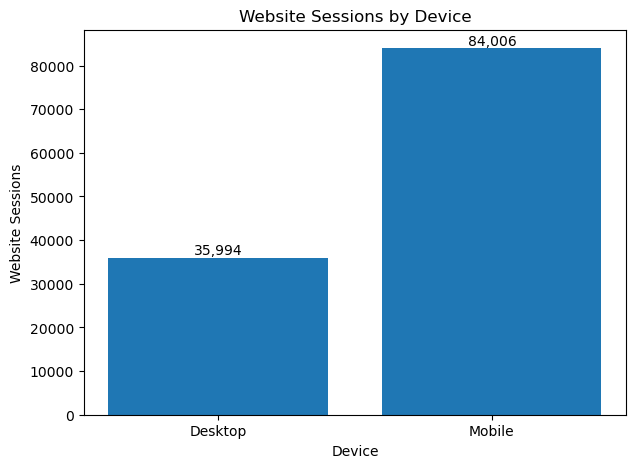

In [34]:
plt.figure(figsize=(7, 5))

plt.bar(
    device_funnel["device"],
    device_funnel["website_visit"]
)

for i, value in enumerate(device_funnel["website_visit"]):
    plt.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.xlabel("Device")
plt.ylabel("Website Sessions")
plt.title("Website Sessions by Device")

plt.show()

**Insights**

- Overall conversion is almost identical across devices: Desktop converts at 6.91%, while Mobile converts at 6.78%. The difference is only 0.13 percentage points, so there is no major device-level conversion gap.
- Mobile drives the majority of traffic: Mobile accounts for 84,006 sessions (70%), compared with 35,994 desktop sessions (30%). Therefore, even small improvements in mobile conversion could have a meaningful business impact.
- Website → Product performance is nearly identical: Desktop converts at 64.94% and Mobile at 64.87%. This suggests that mobile users are reaching product pages at almost the same rate as desktop users.
- Product → Cart is also almost identical: Desktop conversion is 34.83%, compared with 34.89% on Mobile. This is particularly important because your overall analysis identified Product → Cart as the biggest funnel bottleneck, but the problem is not specific to one device.
- Cart → Checkout is slightly better on Desktop: Desktop converts at 60.11%, compared with 59.64% on Mobile. The difference is small (0.47 percentage points).
- Checkout → Purchase: Desktop converts at 50.85%, while Mobile converts at 50.20%. However, the difference is still only 0.65 percentage points, so it is not large enough to indicate a major device-specific problem.

### 4. Funnel Analysis by Acquisition Channel

In [35]:
df["channel"].value_counts()

channel
Paid Ads    53891
Organic     35946
Social      18071
Email       12092
Name: count, dtype: int64

In [36]:
#Create the channel-level funnel

channel_funnel = (
    df.groupby("channel")
      .agg(
          website_visit=("visited_website", "sum"),
          product_views=("viewed_product", "sum"),
          add_to_cart=("added_to_cart", "sum"),
          checkout_started=("checkout_started", "sum"),
          purchases=("purchase_completed", "sum"),
          revenue=("revenue", "sum")
      )
      .reset_index()
)

channel_funnel

,channel,website_visit,product_views,add_to_cart,checkout_started,purchases,revenue
0,Email,12092,7892,2838,1722,884,1811300.315
1,Organic,35946,23327,8158,4909,2448,5090708.447
2,Paid Ads,53891,35011,12058,7161,3619,7536147.080
3,Social,18071,11640,4102,2442,1230,2578443.312


In [37]:
# Calculate overall conversion rate

channel_funnel["conversion_rate"] = ((
    channel_funnel["purchases"] /
    channel_funnel["website_visit"]
) * 100).round(2)

channel_funnel

,channel,website_visit,product_views,add_to_cart,checkout_started,purchases,revenue,conversion_rate
0,Email,12092,7892,2838,1722,884,1811300.315,7.31
1,Organic,35946,23327,8158,4909,2448,5090708.447,6.81
2,Paid Ads,53891,35011,12058,7161,3619,7536147.080,6.72
3,Social,18071,11640,4102,2442,1230,2578443.312,6.81


In [38]:
# Calculate each funnel stage conversion

# Website → Product

channel_funnel["website_to_product"] = ((
    channel_funnel["product_views"] /
    channel_funnel["website_visit"]
) * 100).round(2)

# Product → Cart

channel_funnel["product_to_cart"] = ((
    channel_funnel["add_to_cart"] /
    channel_funnel["product_views"]
) * 100).round(2)

# Cart → Checkout

channel_funnel["cart_to_checkout"] = ((
    channel_funnel["checkout_started"] /
    channel_funnel["add_to_cart"]
) * 100).round(2)

# Checkout → Purchase

channel_funnel["checkout_to_purchase"] = ((
    channel_funnel["purchases"] /
    channel_funnel["checkout_started"]
) * 100).round(2)

channel_funnel

,channel,website_visit,product_views,add_to_cart,checkout_started,purchases,revenue,conversion_rate,website_to_product,product_to_cart,cart_to_checkout,checkout_to_purchase
0,Email,12092,7892,2838,1722,884,1811300.315,7.31,65.27,35.96,60.68,51.34
1,Organic,35946,23327,8158,4909,2448,5090708.447,6.81,64.89,34.97,60.17,49.87
2,Paid Ads,53891,35011,12058,7161,3619,7536147.080,6.72,64.97,34.44,59.39,50.54
3,Social,18071,11640,4102,2442,1230,2578443.312,6.81,64.41,35.24,59.53,50.37


In [39]:
channel_funnel["revenue_per_session"] = ((
    channel_funnel["revenue"] /
    channel_funnel["website_visit"]
)).round(2)

channel_funnel

,channel,website_visit,product_views,add_to_cart,checkout_started,purchases,revenue,conversion_rate,website_to_product,product_to_cart,cart_to_checkout,checkout_to_purchase,revenue_per_session
0,Email,12092,7892,2838,1722,884,1811300.315,7.31,65.27,35.96,60.68,51.34,149.79
1,Organic,35946,23327,8158,4909,2448,5090708.447,6.81,64.89,34.97,60.17,49.87,141.62
2,Paid Ads,53891,35011,12058,7161,3619,7536147.080,6.72,64.97,34.44,59.39,50.54,139.84
3,Social,18071,11640,4102,2442,1230,2578443.312,6.81,64.41,35.24,59.53,50.37,142.68


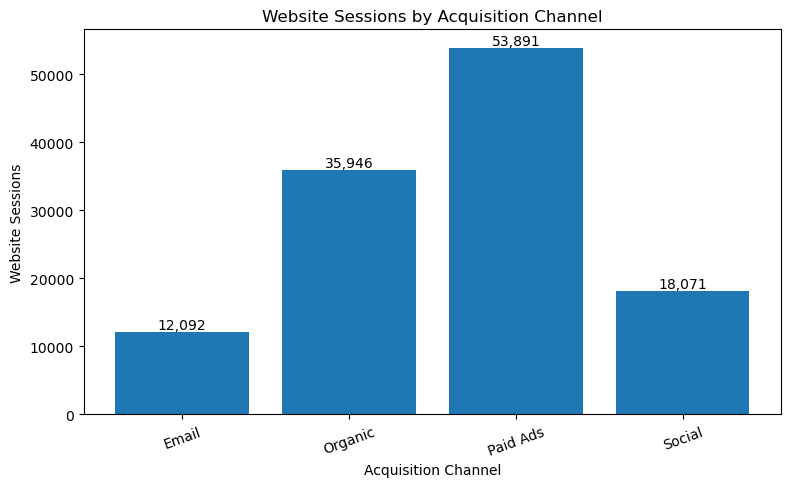

In [40]:
# Sessions by Channel

plt.figure(figsize=(9, 5))

plt.bar(
    channel_funnel["channel"],
    channel_funnel["website_visit"]
)

for i, value in enumerate(channel_funnel["website_visit"]):
    plt.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.xlabel("Acquisition Channel")
plt.ylabel("Website Sessions")
plt.title("Website Sessions by Acquisition Channel")

plt.xticks(rotation=20)

plt.show()

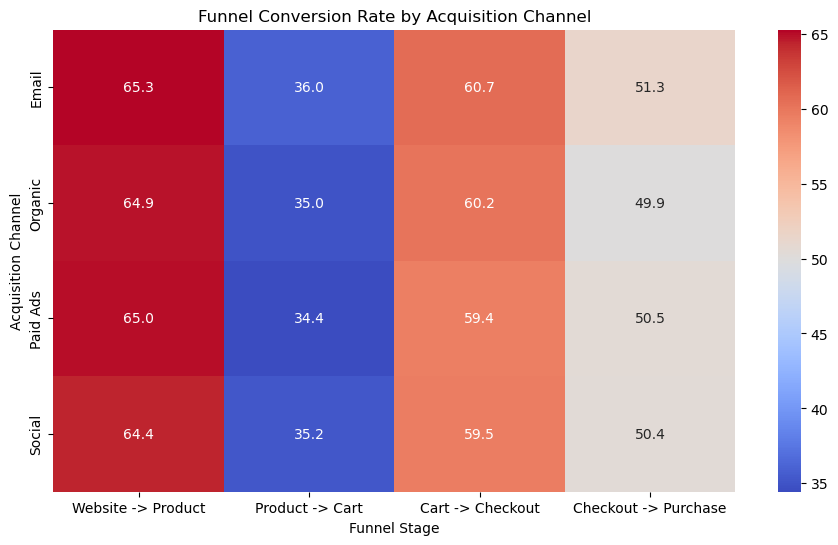

,Website -> Product,Product -> Cart,Cart -> Checkout,Checkout -> Purchase
channel,,,,
Email,65.27,35.96,60.68,51.34
Organic,64.89,34.97,60.17,49.87
Paid Ads,64.97,34.44,59.39,50.54
Social,64.41,35.24,59.53,50.37


In [41]:
heatmap_data = channel_funnel.set_index("channel")[
    [
        "website_to_product",
        "product_to_cart",
        "cart_to_checkout",
        "checkout_to_purchase"
    ]
]

heatmap_data.columns = [
    "Website -> Product",
    "Product -> Cart",
    "Cart -> Checkout",
    "Checkout -> Purchase"
]

plt.figure(figsize=(11, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="coolwarm"
)

plt.title("Funnel Conversion Rate by Acquisition Channel")
plt.xlabel("Funnel Stage")
plt.ylabel("Acquisition Channel")

plt.show()

heatmap_data

In [42]:
channel_funnel

,channel,website_visit,product_views,add_to_cart,checkout_started,purchases,revenue,conversion_rate,website_to_product,product_to_cart,cart_to_checkout,checkout_to_purchase,revenue_per_session
0,Email,12092,7892,2838,1722,884,1811300.315,7.31,65.27,35.96,60.68,51.34,149.79
1,Organic,35946,23327,8158,4909,2448,5090708.447,6.81,64.89,34.97,60.17,49.87,141.62
2,Paid Ads,53891,35011,12058,7161,3619,7536147.080,6.72,64.97,34.44,59.39,50.54,139.84
3,Social,18071,11640,4102,2442,1230,2578443.312,6.81,64.41,35.24,59.53,50.37,142.68


**Insights**

- Paid Ads is the largest acquisition channel, generating 53,891 sessions, 3,619 purchases, and ₹7.54M revenue.
- Email has the highest conversion rate at 7.31% and the highest revenue per session at approximately ₹149.79.
- Organic is a strong balanced channel, generating 35,946 sessions, 6.81% conversion, and ₹5.09M revenue.
- Social has 18,071 sessions and 6.81% conversion, performing similarly to Organic.
- Product → Cart is the biggest funnel bottleneck across every channel, with conversion ranging from 34.44% to 35.96%.
- The small variation in Product → Cart conversion suggests the bottleneck is not strongly channel-specific.
- Checkout → Purchase performance is also consistent across channels, ranging from 49.87% to 51.34%.
- Overall conversion varies only from 6.72% to 7.31%, indicating that acquisition channel is not a major driver of overall conversion differences.

### 5.Campaign Performance Analysis 

In [43]:
df["campaign_type"].value_counts()

campaign_type
Discount      60121
New Launch    36064
Influencer    23815
Name: count, dtype: int64

In [44]:
df.head()

,user_id,session_id,date,month,channel,campaign_type,device,user_type,region,visited_website,...,discount_applied,order_value,revenue,funnel_stage,funnel_dropoff_stage,funnel_depth,month_name,cart_abandoned,checkout_abandoned,high_intent_session
0,221958,1,2025-08-16,2025-08,Organic,New Launch,Mobile,New,Metro,1,...,0,499.00,0.000,Visited Website,Product View,1,August,0,0,0
1,771155,2,2025-12-16,2025-12,Organic,Influencer,Mobile,New,Non-Metro,1,...,0,499.00,0.000,Added to Cart,Checkout,3,December,1,0,1
2,231932,3,2025-07-17,2025-07,Organic,Influencer,Mobile,New,Non-Metro,1,...,0,499.00,0.000,Viewed Product,Add to Cart,2,July,0,0,0
3,465838,4,2025-07-04,2025-07,Paid Ads,Discount,Mobile,Returning,Metro,1,...,1,2000.95,1800.855,Purchased,No Drop-off,5,July,0,0,1
4,359178,5,2025-08-10,2025-08,Paid Ads,Influencer,Mobile,Returning,Non-Metro,1,...,0,499.00,0.000,Visited Website,Product View,1,August,0,0,0


In [45]:
#Create campaign level summary

campaign_analysis = (
    df.groupby("campaign_type")
      .agg(
          website_visits=("visited_website", "sum"),
          product_views=("viewed_product", "sum"),
          add_to_cart=("added_to_cart", "sum"),
          checkout_started=("checkout_started", "sum"),
          purchases=("purchase_completed", "sum"),
          revenue=("revenue", "sum"),
          order_value=("order_value", "sum")
      )
      .reset_index()
)

campaign_analysis

,campaign_type,website_visits,product_views,add_to_cart,checkout_started,purchases,revenue,order_value
0,Discount,60121,38950,13541,8087,4107,8526583.032,36970109.81
1,Influencer,23815,15423,5465,3240,1626,3367310.800,14637793.82
2,New Launch,36064,23497,8150,4907,2448,5122705.322,22187617.31


In [46]:
#Overall Campaign convertion

campaign_analysis["conversion_rate"] = ((
    campaign_analysis["purchases"] /
    campaign_analysis["website_visits"]
) * 100).round(2)

campaign_analysis

,campaign_type,website_visits,product_views,add_to_cart,checkout_started,purchases,revenue,order_value,conversion_rate
0,Discount,60121,38950,13541,8087,4107,8526583.032,36970109.81,6.83
1,Influencer,23815,15423,5465,3240,1626,3367310.800,14637793.82,6.83
2,New Launch,36064,23497,8150,4907,2448,5122705.322,22187617.31,6.79


In [47]:
# Calculate funnel convertion by campaign

# Website -> Product
campaign_analysis["website_to_product"] = ((
    campaign_analysis["product_views"] /
    campaign_analysis["website_visits"]
) * 100).round(2)

#product -> cart
campaign_analysis["product_to_cart"] = ((
    campaign_analysis["add_to_cart"] /
    campaign_analysis["product_views"]
) * 100).round(2)

#cart -> checkout

campaign_analysis["cart_to_checkout"] = ((
    campaign_analysis["checkout_started"] /
    campaign_analysis["add_to_cart"]
) * 100).round(2)

#checkout -> purchase

campaign_analysis["checkout_to_purchase"] = ((
    campaign_analysis["purchases"] /
    campaign_analysis["checkout_started"]
) * 100).round(2)

campaign_analysis

,campaign_type,website_visits,product_views,add_to_cart,checkout_started,purchases,revenue,order_value,conversion_rate,website_to_product,product_to_cart,cart_to_checkout,checkout_to_purchase
0,Discount,60121,38950,13541,8087,4107,8526583.032,36970109.81,6.83,64.79,34.77,59.72,50.79
1,Influencer,23815,15423,5465,3240,1626,3367310.800,14637793.82,6.83,64.76,35.43,59.29,50.19
2,New Launch,36064,23497,8150,4907,2448,5122705.322,22187617.31,6.79,65.15,34.69,60.21,49.89


In [48]:
campaign_analysis[["campaign_type","website_to_product","product_to_cart","cart_to_checkout","checkout_to_purchase"]]

,campaign_type,website_to_product,product_to_cart,cart_to_checkout,checkout_to_purchase
0,Discount,64.79,34.77,59.72,50.79
1,Influencer,64.76,35.43,59.29,50.19
2,New Launch,65.15,34.69,60.21,49.89


In [49]:
# revenue per session

campaign_analysis["revenue_per_session"] = ((
    campaign_analysis["revenue"] /
    campaign_analysis["website_visits"]
)).round(2)

campaign_analysis

,campaign_type,website_visits,product_views,add_to_cart,checkout_started,purchases,revenue,order_value,conversion_rate,website_to_product,product_to_cart,cart_to_checkout,checkout_to_purchase,revenue_per_session
0,Discount,60121,38950,13541,8087,4107,8526583.032,36970109.81,6.83,64.79,34.77,59.72,50.79,141.82
1,Influencer,23815,15423,5465,3240,1626,3367310.800,14637793.82,6.83,64.76,35.43,59.29,50.19,141.39
2,New Launch,36064,23497,8150,4907,2448,5122705.322,22187617.31,6.79,65.15,34.69,60.21,49.89,142.04


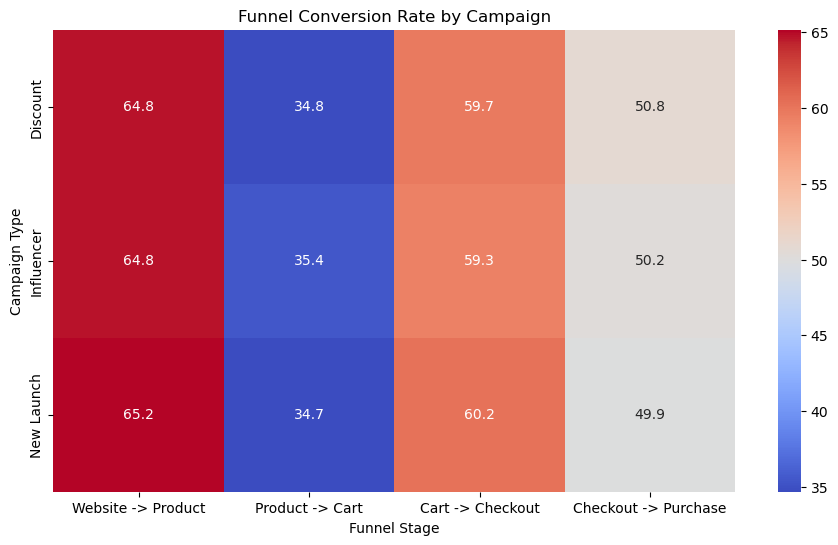

In [50]:
#Funnel convertion by campaign

heatmap_data = campaign_analysis.set_index("campaign_type")[
    [
        "website_to_product",
        "product_to_cart",
        "cart_to_checkout",
        "checkout_to_purchase"
    ]
]

heatmap_data.columns = [
    "Website -> Product",
    "Product -> Cart",
    "Cart -> Checkout",
    "Checkout -> Purchase"
]

plt.figure(figsize=(11, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="coolwarm"
)

plt.title("Funnel Conversion Rate by Campaign")
plt.xlabel("Funnel Stage")
plt.ylabel("Campaign Type")

plt.show()



In [51]:
campaign_analysis

,campaign_type,website_visits,product_views,add_to_cart,checkout_started,purchases,revenue,order_value,conversion_rate,website_to_product,product_to_cart,cart_to_checkout,checkout_to_purchase,revenue_per_session
0,Discount,60121,38950,13541,8087,4107,8526583.032,36970109.81,6.83,64.79,34.77,59.72,50.79,141.82
1,Influencer,23815,15423,5465,3240,1626,3367310.800,14637793.82,6.83,64.76,35.43,59.29,50.19,141.39
2,New Launch,36064,23497,8150,4907,2448,5122705.322,22187617.31,6.79,65.15,34.69,60.21,49.89,142.04


- Discount campaigns generate the highest scale, with 60,121 sessions, 4,107 purchases, and ₹8.53M revenue.
- New Launch campaigns have the highest revenue per session at ₹142.04, slightly ahead of Discount (₹141.82) and Influencer (₹141.39).
- Conversion rates are almost identical across all campaign types:
     * Discount: 6.83%
     * Influencer: 6.83%
     * New Launch: 6.79%
- Website → Product conversion is also very consistent, ranging from 64.76% to 65.15%, indicating that campaign type has little impact on initial product discovery.
- Product → Cart remains a major bottleneck across all campaigns, with conversion ranging from 34.69% to 35.43%.
- Influencer campaigns have the highest Product → Cart conversion at 35.43%, but the difference from New Launch (34.69%) is relatively small.
- Cart → Checkout conversion is strongest for New Launch campaigns at 60.21%, while Influencer campaigns are lowest at 59.29%.
- Checkout → Purchase conversion is relatively consistent, ranging from 49.89% to 50.79%.
- The overall similarity in conversion rates suggests that campaign type is not a major driver of funnel conversion in this dataset.
Discount campaigns are the strongest channel by overall business scale, while New Launch campaigns are slightly more efficient in terms of revenue per session.

### 6. Cart Abandonment Analysis

In [52]:
df.columns

Index(['user_id', 'session_id', 'date', 'month', 'channel', 'campaign_type',
       'device', 'user_type', 'region', 'visited_website', 'viewed_product',
       'added_to_cart', 'checkout_started', 'purchase_completed',
       'discount_applied', 'order_value', 'revenue', 'funnel_stage',
       'funnel_dropoff_stage', 'funnel_depth', 'month_name', 'cart_abandoned',
       'checkout_abandoned', 'high_intent_session'],
      dtype='object')

In [53]:
df[['visited_website', 'viewed_product','added_to_cart', 'checkout_started', 'purchase_completed','cart_abandoned', 'checkout_abandoned']].head()  

,visited_website,viewed_product,added_to_cart,checkout_started,purchase_completed,cart_abandoned,checkout_abandoned
0,1,0,0,0,0,0,0
1,1,1,1,0,0,1,0
2,1,1,0,0,0,0,0
3,1,1,1,1,1,0,0
4,1,0,0,0,0,0,0


In [54]:
# Calculate total cart sessions

cart_sessions = df[df["added_to_cart"] == 1]

total_cart_sessions = cart_sessions["session_id"].nunique()

total_cart_sessions

27156

In [55]:
#Calculate abandoned cart sessions

abandoned_cart_sessions = cart_sessions[cart_sessions["cart_abandoned"] == 1]["session_id"].nunique()
abandoned_cart_sessions

10922

In [56]:
#Calculate completed cart sessions


completed_cart_sessions = (
    total_cart_sessions - abandoned_cart_sessions
)

completed_cart_sessions

16234

In [57]:
# Calculating cart abondonment rate

cart_abandonment_rate = round((abandoned_cart_sessions / total_cart_sessions) * 100,2)

cart_abandonment_rate

40.22

In [58]:
#Calculate cart completion rate

cart_completion_rate = 100 - cart_abandonment_rate

cart_completion_rate

59.78

In [59]:
kpi_labels = [
    "Total Cart Sessions",
    "Abandoned Carts",
    "Completed Carts",
    "Cart Abandonment Rate",
    "Cart Completion Rate"
]

kpi_values = [
    f"{total_cart_sessions:,}",
    f"{abandoned_cart_sessions:,}",
    f"{completed_cart_sessions:,}",
    f"{cart_abandonment_rate:.2f}%",
    f"{cart_completion_rate:.2f}%"
]

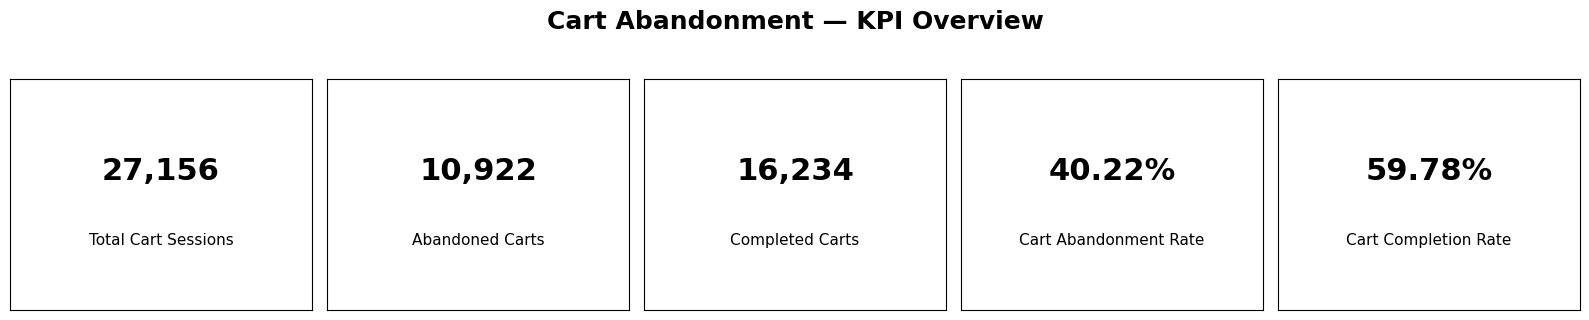

In [60]:
# Create KPI cards

fig, axes = plt.subplots(1,5,figsize=(16, 3))

fig.suptitle("Cart Abandonment — KPI Overview",fontsize=18,fontweight="bold",y=1.05)


for ax, label, value in zip(axes,kpi_labels,kpi_values):

    # KPI value
    ax.text(0.5,0.60,value,ha="center",va="center",fontsize=22,fontweight="bold")

    # KPI label
    ax.text( 0.5, 0.30,label,ha="center",va="center",fontsize=11)

    # Remove axes
    ax.set_xticks([])
    ax.set_yticks([])


plt.tight_layout()

plt.show()

In [61]:
# Analyze cart abandonment by device

cart_device = (df[df["added_to_cart"] == 1].groupby("device")
    .agg(
        cart_sessions=("session_id", "nunique"),
        abandoned_carts=("cart_abandoned", "sum")
    )
    .reset_index()
)


# Cart Abandonment rate

cart_device["abandonment_rate"] = ((
    cart_device["abandoned_carts"] /
    cart_device["cart_sessions"]
) * 100).round(2)


cart_device

,device,cart_sessions,abandoned_carts,abandonment_rate
0,Desktop,8140,3247,39.89
1,Mobile,19016,7675,40.36


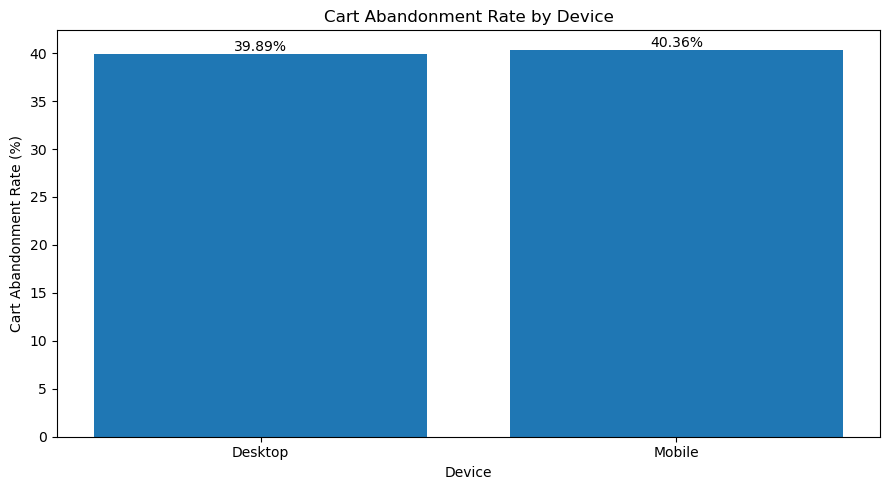

In [62]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    cart_device["device"],
    cart_device["abandonment_rate"]
)

for bar, value in zip(
    bars,
    cart_device["abandonment_rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.xlabel("Device")
plt.ylabel("Cart Abandonment Rate (%)")
plt.title("Cart Abandonment Rate by Device")

plt.tight_layout()
plt.show()

In [63]:
#Analyze cart abandonment by acquisition channel

cart_channel = (df[df["added_to_cart"] == 1].groupby("channel")
    .agg(
        cart_sessions=("session_id", "nunique"),
        abandoned_carts=("cart_abandoned", "sum")
    )
    .reset_index()
)

# Cart Abandonment rate

cart_channel["abandonment_rate"] = ((
    cart_channel["abandoned_carts"] /
    cart_channel["cart_sessions"]
) * 100).round(2)


cart_channel

,channel,cart_sessions,abandoned_carts,abandonment_rate
0,Email,2838,1116,39.32
1,Organic,8158,3249,39.83
2,Paid Ads,12058,4897,40.61
3,Social,4102,1660,40.47


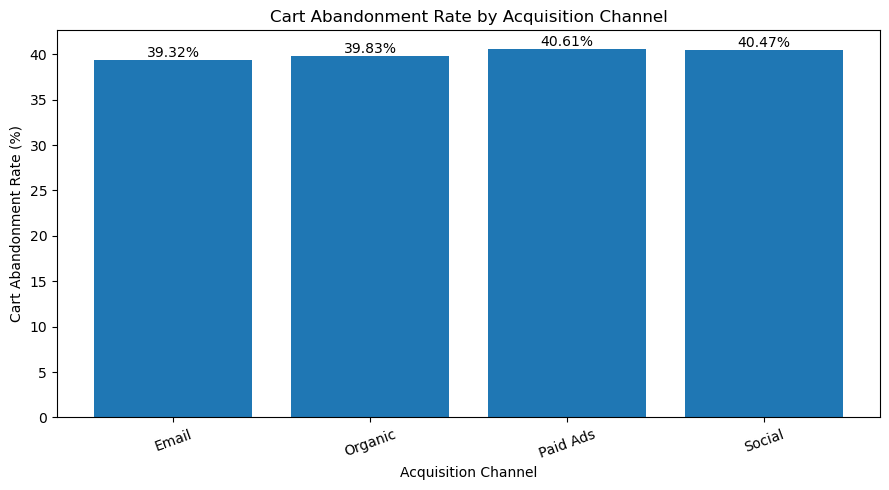

In [64]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    cart_channel["channel"],
    cart_channel["abandonment_rate"]
)

for bar, value in zip(bars,cart_channel["abandonment_rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.xlabel("Acquisition Channel")
plt.ylabel("Cart Abandonment Rate (%)")
plt.title("Cart Abandonment Rate by Acquisition Channel")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [65]:
# Analyze cart abandonment by campaign type

cart_campaign = (df[df["added_to_cart"] == 1].groupby("campaign_type")
    .agg(
        cart_sessions=("session_id", "nunique"),
        abandoned_carts=("cart_abandoned", "sum")
    )
    .reset_index()
)

# Cart Abandonment rate

cart_campaign["abandonment_rate"] = ((
    cart_campaign["abandoned_carts"] /
    cart_campaign["cart_sessions"]
) * 100).round(2)

cart_campaign

,campaign_type,cart_sessions,abandoned_carts,abandonment_rate
0,Discount,13541,5454,40.28
1,Influencer,5465,2225,40.71
2,New Launch,8150,3243,39.79


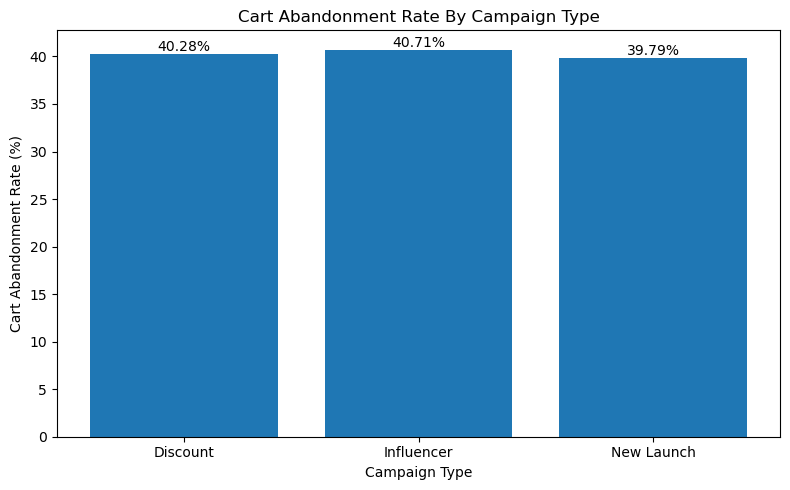

In [66]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    cart_campaign["campaign_type"],
    cart_campaign["abandonment_rate"]
)

for bar, value in zip(bars,cart_campaign["abandonment_rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.xlabel("Campaign Type")
plt.ylabel("Cart Abandonment Rate (%)")
plt.title("Cart Abandonment Rate By Campaign Type")

plt.tight_layout()
plt.show()

In [67]:
# Analyze cart abandonment new vs returning users

cart_user_type = (
    df[df["added_to_cart"] == 1]
    .groupby("user_type")
    .agg(
        cart_sessions=("session_id", "nunique"),
        abandoned_carts=("cart_abandoned", "sum")
    )
    .reset_index()
)

# Cart Abandonment rate

cart_user_type["abandonment_rate"] = ((
    cart_user_type["abandoned_carts"] /
    cart_user_type["cart_sessions"]
) * 100).round(2)


cart_user_type

,user_type,cart_sessions,abandoned_carts,abandonment_rate
0,New,17730,7072,39.89
1,Returning,9426,3850,40.84


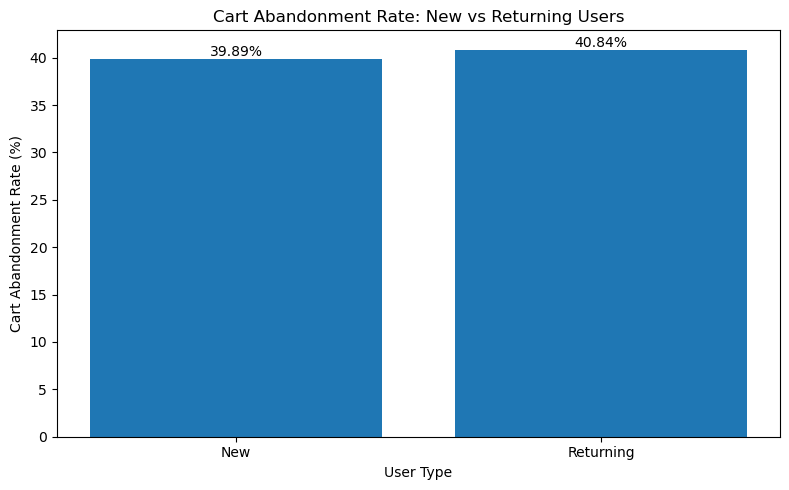

In [68]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    cart_user_type["user_type"],
    cart_user_type["abandonment_rate"]
)

for bar, value in zip(bars,cart_user_type["abandonment_rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.xlabel("User Type")
plt.ylabel("Cart Abandonment Rate (%)")
plt.title("Cart Abandonment Rate: New vs Returning Users")

plt.tight_layout()
plt.show()

**Cart Abandonment Analysis — Key Insights**
    
**Overall Performance**
- 27,156 sessions added products to the cart.
- 10,922 sessions were abandoned, resulting in a 40.22% cart abandonment rate.
- 16,234 sessions progressed beyond the cart, giving a 59.78% completion rate.
- This means around 4 out of every 10 cart sessions are abandoned, making cart abandonment an important conversion opportunity.
  
**By Device**
- Mobile has a slightly higher abandonment rate: 40.36% vs 39.89% for Desktop.
- The difference is only 0.47 percentage points, so device does not appear to be a major driver of cart abandonment.
- Mobile has 7,675 abandoned carts because it has much higher cart volume.
  
**By Acquisition Channel**
- Paid Ads has the highest abandonment rate: 40.61%.
- Social is close behind: 40.47%.
- Email has the lowest abandonment rate: 39.32%.
- However, the difference between the highest and lowest channels is only 1.29 percentage points.
- Paid Ads has the largest number of abandoned carts (4,897) because it generates the most cart sessions.
  
**By Campaign Type**
- Influencer campaigns have the highest abandonment rate: 40.71%.
- Discount campaigns: 40.28%.
- New Launch campaigns have the lowest: 39.79%.
- The difference is only 0.92 percentage points, suggesting campaign type has limited impact on cart abandonment.
  
**By User Type**
- Returning users have a slightly higher abandonment rate: 40.84%.
- New users: 39.89%.
- The difference is only 0.95 percentage points.
- **This is interesting because returning users might generally be expected to have higher purchase intent, but in this dataset they show slightly
higher cart abandonment.**

### 7. Checkout Abandonment Analysis 

In [69]:
# Calculate overall KPI's

checkout_df = df[
    df["checkout_started"] == 1
]

# Calculating total checkout sessions

total_checkout_sessions = (
    checkout_df["session_id"].nunique()
)

total_checkout_sessions

16234

In [70]:
# Calculate completed purchases

completed_purchase_sessions = (
    checkout_df.loc[
        checkout_df["purchase_completed"] == 1,
        "session_id"
    ].nunique()
)

completed_purchase_sessions

8181

In [71]:
# Calculate checkout abandonment

checkout_abandoned_sessions = (
    total_checkout_sessions -
    completed_purchase_sessions
)

checkout_abandoned_sessions

8053

In [72]:
#Calculate checkout abandonment rate

checkout_abandonment_rate = round((
    checkout_abandoned_sessions /
    total_checkout_sessions
) * 100,2)


checkout_abandonment_rate

49.61

In [73]:
#Calculate checkout completion rate

checkout_completion_rate = round((
    completed_purchase_sessions /
    total_checkout_sessions
) * 100,2)

checkout_completion_rate

50.39

In [74]:
#Creating KPI cards

kpi_labels = [
    "Total Checkout Sessions",
    "Abandoned Checkouts",
    "Completed Checkouts",
    "Checkout Abandonment Rate",
    "Checkout Completion Rate"
]

kpi_values = [
    f"{total_checkout_sessions:,}",
    f"{checkout_abandoned_sessions:,}",
    f"{completed_purchase_sessions:,}",
    f"{checkout_abandonment_rate:.2f}%",
    f"{checkout_completion_rate:.2f}%"
]

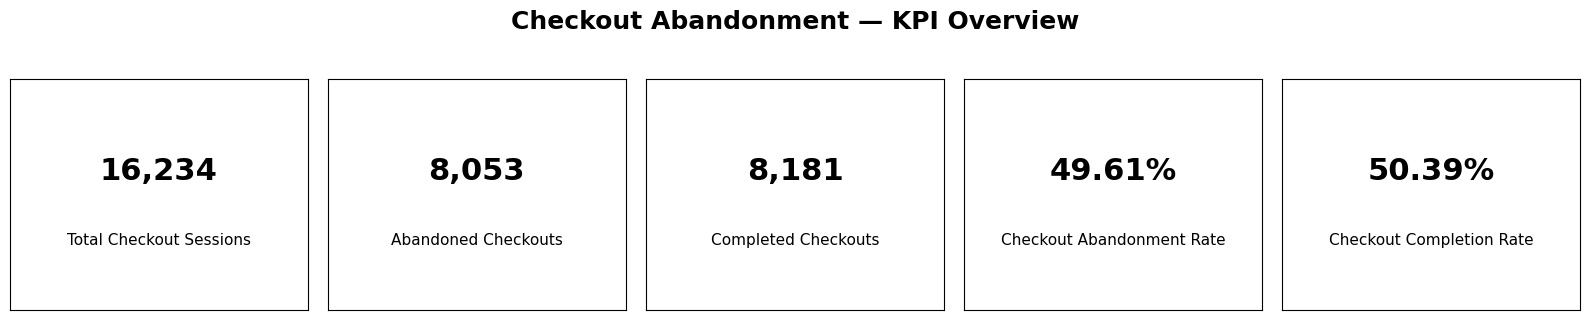

In [75]:
fig, axes = plt.subplots(1,5,figsize=(16, 3))

fig.suptitle("Checkout Abandonment — KPI Overview",fontsize=18,fontweight="bold",y=1.05)


for ax, label, value in zip(axes,kpi_labels,kpi_values):

    # KPI value
    ax.text(0.5,0.60,value,ha="center",va="center",fontsize=22,fontweight="bold")

    # KPI label
    ax.text( 0.5, 0.30,label,ha="center",va="center",fontsize=11)

    # Remove axes
    ax.set_xticks([])
    ax.set_yticks([])


plt.tight_layout()

plt.show()

In [76]:
#Analyze checkout abandonment by device

checkout_device = (
    df[df["checkout_started"] == 1]
    .groupby("device")
    .agg(
        checkout_sessions=("session_id", "nunique"),
        abandoned_checkouts=("checkout_abandoned", "sum")
    )
    .reset_index()
)


#calculate Checkout Abandonment rate

checkout_device["abandonment_rate"] = ((
    checkout_device["abandoned_checkouts"] /
    checkout_device["checkout_sessions"]
) * 100).round(2)

checkout_device

,device,checkout_sessions,abandoned_checkouts,abandonment_rate
0,Desktop,4893,2405,49.15
1,Mobile,11341,5648,49.80


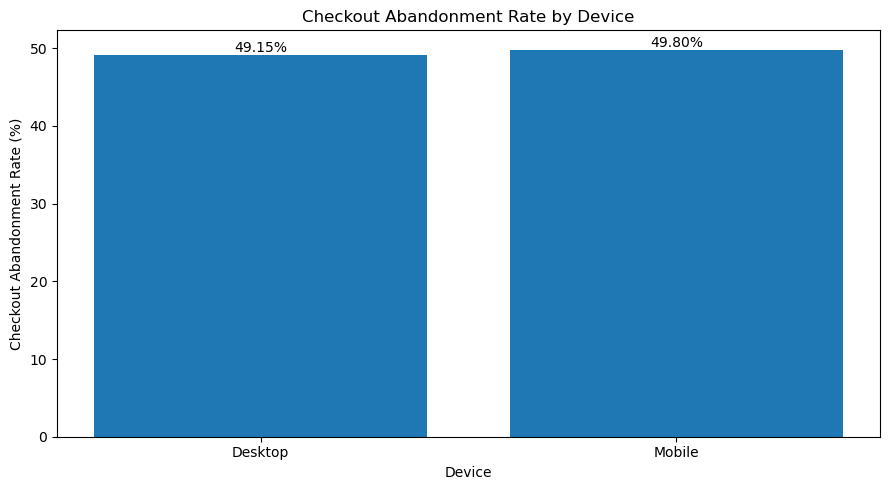

In [77]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    checkout_device["device"],
    checkout_device["abandonment_rate"]
)

for bar, value in zip(bars, checkout_device["abandonment_rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.xlabel("Device")
plt.ylabel("Checkout Abandonment Rate (%)")
plt.title("Checkout Abandonment Rate by Device")

plt.tight_layout()
plt.show()

In [78]:
# Analyze checkout abandonment by acquisition channel

checkout_channel = (
    df[df["checkout_started"] == 1]
    .groupby("channel")
    .agg(
        checkout_sessions=("session_id", "nunique"),
        abandoned_checkouts=("checkout_abandoned", "sum")
    )
    .reset_index()
)


checkout_channel["abandonment_rate"] = ((
    checkout_channel["abandoned_checkouts"] /
    checkout_channel["checkout_sessions"]
) * 100).round(2)


checkout_channel

,channel,checkout_sessions,abandoned_checkouts,abandonment_rate
0,Email,1722,838,48.66
1,Organic,4909,2461,50.13
2,Paid Ads,7161,3542,49.46
3,Social,2442,1212,49.63


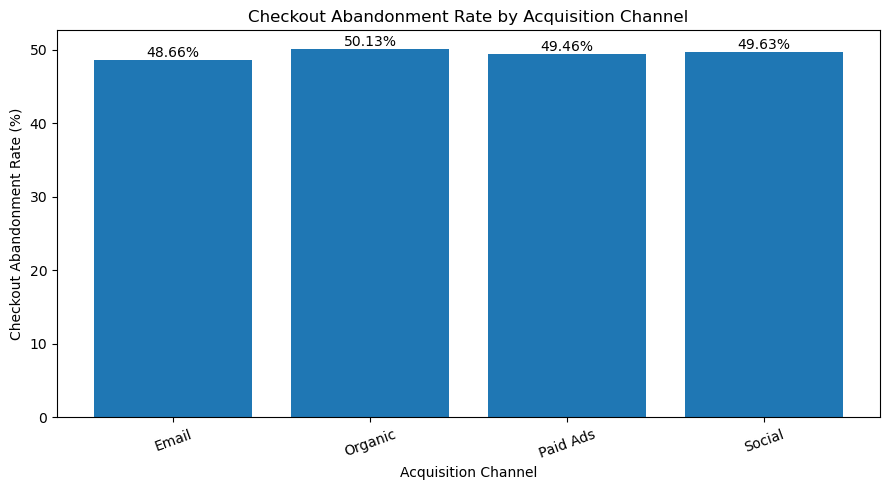

In [79]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    checkout_channel["channel"],
    checkout_channel["abandonment_rate"]
)

for bar, value in zip(bars,checkout_channel["abandonment_rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.xlabel("Acquisition Channel")
plt.ylabel("Checkout Abandonment Rate (%)")
plt.title("Checkout Abandonment Rate by Acquisition Channel")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [80]:
# Analyze checkout abandonment by campaign type

checkout_campaign = (
    df[df["checkout_started"] == 1]
    .groupby("campaign_type")
    .agg(
        checkout_sessions=("session_id", "nunique"),
        abandoned_checkouts=("checkout_abandoned", "sum")
    )
    .reset_index()
)

checkout_campaign["abandonment_rate"] = ((
    checkout_campaign["abandoned_checkouts"] /
    checkout_campaign["checkout_sessions"]
) * 100).round(2)

checkout_campaign

,campaign_type,checkout_sessions,abandoned_checkouts,abandonment_rate
0,Discount,8087,3980,49.21
1,Influencer,3240,1614,49.81
2,New Launch,4907,2459,50.11


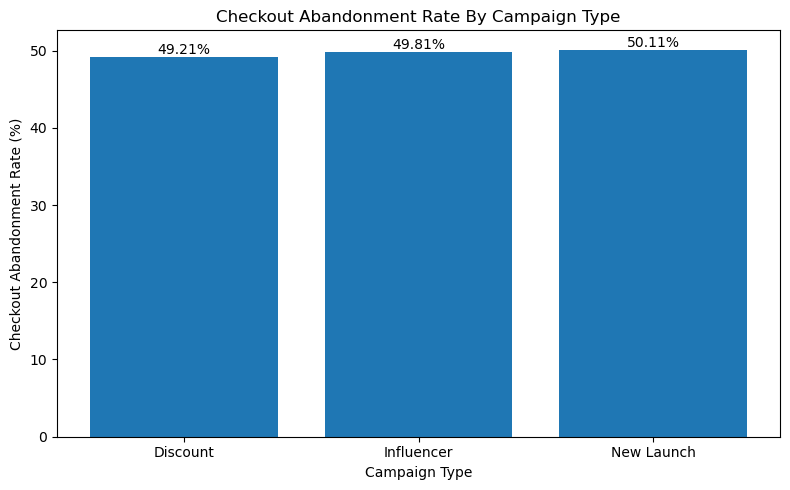

In [81]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    checkout_campaign["campaign_type"],
    checkout_campaign["abandonment_rate"]
)

for bar, value in zip(bars,checkout_campaign["abandonment_rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.xlabel("Campaign Type")
plt.ylabel("Checkout Abandonment Rate (%)")
plt.title("Checkout Abandonment Rate By Campaign Type")

plt.tight_layout()
plt.show()

In [82]:
# Analyze checkout abandonment  New vs Returning users

checkout_user_type = (
    df[df["checkout_started"] == 1]
    .groupby("user_type")
    .agg(
        checkout_sessions=("session_id", "nunique"),
        abandoned_checkouts=("checkout_abandoned", "sum")
    )
    .reset_index()
)

checkout_user_type["abandonment_rate"] = ((
    checkout_user_type["abandoned_checkouts"] /
    checkout_user_type["checkout_sessions"]
) * 100).round(2)


checkout_user_type

,user_type,checkout_sessions,abandoned_checkouts,abandonment_rate
0,New,10658,5260,49.35
1,Returning,5576,2793,50.09


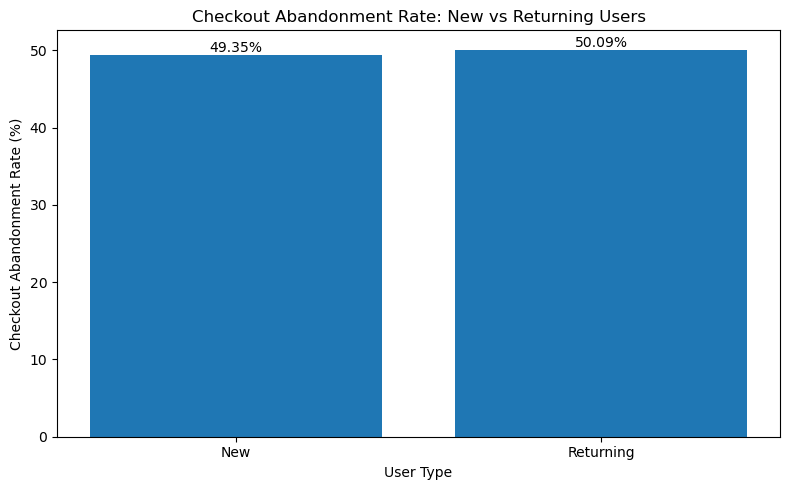

In [83]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    checkout_user_type["user_type"],
    checkout_user_type["abandonment_rate"]
)

for bar, value in zip(bars,checkout_user_type["abandonment_rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.xlabel("User Type")
plt.ylabel("Checkout Abandonment Rate (%)")
plt.title("Checkout Abandonment Rate: New vs Returning Users")

plt.tight_layout()
plt.show()

**Checkout Abandonment Analysis — Key Insights**

**Overall**

- 16,234 sessions started checkout, but only 8,181 completed a purchase.
- 8,053 checkout sessions were abandoned, resulting in a 49.61% checkout abandonment rate.
- In other words, almost 1 in 2 checkout sessions does not result in a purchase.
- Checkout abandonment is higher than your 40.22% cart abandonment rate, making Checkout → Purchase a critical conversion problem.
  
**By Device** 
- Mobile abandonment: 49.80%
- Desktop abandonment: 49.15%
- Mobile is only 0.65 percentage points higher, so device does not appear to be a major driver of checkout abandonment.
- Mobile has the larger number of abandoned checkouts (5,648) because it generates much more checkout traffic.
  
**By Acquisition Channel**
- Organic has the highest abandonment rate: 50.13%.
- Email has the lowest abandonment rate: 48.66%.
- Paid Ads: 49.46%
- Social: 49.63%
- The difference between the highest and lowest channel is only 1.47 percentage points, indicating that channel has a relatively small impact on checkout abandonment.
- Paid Ads has the largest number of abandoned checkouts (3,542) due to its high checkout volume.
  
**By Campaign Type**
- New Launch has the highest abandonment: 50.11%.
- Influencer: 49.81%
- Discount: 49.21%
- The difference is only 0.90 percentage points, so campaign type does not appear to be a major driver.
  
**By User Type**
- Returning users: 50.09% abandonment
- New users: 49.35% abandonment
- Returning users abandon checkout 0.74 percentage points more than new users.
- This is consistent with your cart analysis, where returning users also had slightly higher abandonment.